# Задача 7. Классификация: SI больше 8

**Цель:** определить, превышает ли индекс селективности соединения значение 8.

Здесь уже порог не статистический , а предметный. тут конкретно спрашивается , нужно ли нам вкладываться в соединение или отбросить


**Особенность постановки это дисбаланс классов,** порогу удовлетворяют 35.7% объектов, поэтому аccuracy здесь обманчива, Так что берём PR-AUC добавляем class_weight='balanced' и делаем групповую кросс-валидацию

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402
from src import modeling as mdl  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path.cwd().parent / "reports" / "figures"
RES_DIR = Path.cwd().parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
features, targets, groups, clean_report = du.load_dataset()
target = targets["si_gt_8"]

print(f"Признаков: {features.shape[1]}, объектов: {features.shape[0]}")
print(f"Целевая переменная: SI > 8")
print(f"Класс 1: {int(target.sum())} объектов ({target.mean():.1%})")
print(f"Класс 0: {int((1 - target).sum())} объектов ({1 - target.mean():.1%})")

Признаков: 178, объектов: 1001
Целевая переменная: SI > 8
Класс 1: 357 объектов (35.7%)
Класс 0: 644 объектов (64.3%)


## 2. Разбиение на обучение и отложенный тест

In [3]:
X_train, X_test, y_train, y_test, groups_train = mdl.group_train_test_split(
    features, target, groups
)
train_groups = set(groups[np.isin(features.index, X_train.index)])
test_groups = set(groups[np.isin(features.index, X_test.index)])

print(f"train: {X_train.shape[0]} объектов, доля класса 1 = {y_train.mean():.3f}")
print(f"test:  {X_test.shape[0]} объектов, доля класса 1 = {y_test.mean():.3f}")
print(f"Пересечение групп train/test: {len(train_groups & test_groups)}")

train: 798 объектов, доля класса 1 = 0.372
test:  203 объектов, доля класса 1 = 0.296
Пересечение групп train/test: 0


## 3. Подбор гиперпараметров и сравнение моделей

In [4]:
cv_table, fitted = mdl.search_candidates(
    mdl.classification_candidates(), X_train, y_train, groups_train,
    scoring="roc_auc", stratified=True, task="si8_clf",
)
display(cv_table.drop(columns=["комментарий"]).round(4))

Baseline (частый класс)  CV roc_auc =  0.5000 (±0.0000)


Logistic Regression      CV roc_auc =  0.6906 (±0.0327)
kNN                      CV roc_auc =  0.6992 (±0.0663)


SVC (RBF)                CV roc_auc =  0.6863 (±0.0528)


Random Forest            CV roc_auc =  0.6981 (±0.0420)


Extra Trees              CV roc_auc =  0.7080 (±0.0385)


LightGBM                 CV roc_auc =  0.6891 (±0.0371)


XGBoost                  CV roc_auc =  0.6898 (±0.0559)


,модель,CV roc_auc,std,лучшие гиперпараметры,число обучений
0,Extra Trees,0.7080,0.0385,"{'class_weight': None, 'max_depth': 14, 'max_f...",150
1,kNN,0.6992,0.0663,"{'n_neighbors': 18, 'p': 1, 'weights': 'distan...",150
2,Random Forest,0.6981,0.0420,"{'class_weight': 'balanced', 'max_depth': 24, ...",150
3,Logistic Regression,0.6906,0.0327,"{'C': 70.45684, 'class_weight': 'balanced', 'p...",150
4,XGBoost,0.6898,0.0559,"{'colsample_bytree': 0.68333, 'learning_rate':...",150
5,LightGBM,0.6891,0.0371,"{'class_weight': 'balanced', 'colsample_bytree...",150
6,SVC (RBF),0.6863,0.0528,"{'C': 28.01635, 'class_weight': 'balanced', 'g...",150
7,Baseline (частый класс),0.5000,0.0000,{},5


In [5]:
display(cv_table[["модель", "комментарий", "лучшие гиперпараметры"]]
        .set_index("модель"))

,комментарий,лучшие гиперпараметры
модель,,
Extra Trees,усиленная рандомизация разбиений,"{'class_weight': None, 'max_depth': 14, 'max_f..."
kNN,метрическая модель,"{'n_neighbors': 18, 'p': 1, 'weights': 'distan..."
Random Forest,бэггинг деревьев,"{'class_weight': 'balanced', 'max_depth': 24, ..."
Logistic Regression,линейный baseline с регуляризацией,"{'C': 70.45684, 'class_weight': 'balanced', 'p..."
XGBoost,альтернативная реализация бустинга,"{'colsample_bytree': 0.68333, 'learning_rate':..."
LightGBM,"градиентный бустинг, основной кандидат","{'class_weight': 'balanced', 'colsample_bytree..."
SVC (RBF),нелинейная модель на ядре,"{'C': 28.01635, 'class_weight': 'balanced', 'g..."
Baseline (частый класс),нижняя граница качества: ROC-AUC = 0.5 по пост...,{}


## 4. Оценка на отложенном тесте

In [6]:
test_table = mdl.evaluate_on_test(fitted, X_test, y_test, task="classification")
display(test_table.round(3))
test_table.to_csv(RES_DIR / "si8_clf_test_metrics.csv", index=False)

,модель,ROC-AUC,PR-AUC,Accuracy,Balanced acc.,F1
0,XGBoost,0.786,0.638,0.739,0.621,0.430
1,Extra Trees,0.775,0.635,0.734,0.637,0.471
2,Random Forest,0.774,0.624,0.734,0.642,0.481
3,kNN,0.754,0.603,0.700,0.651,0.512
4,SVC (RBF),0.737,0.605,0.690,0.683,0.559
5,LightGBM,0.733,0.563,0.704,0.626,0.464
6,Logistic Regression,0.676,0.495,0.680,0.642,0.504
7,Baseline (частый класс),0.500,0.296,0.704,0.500,0.000


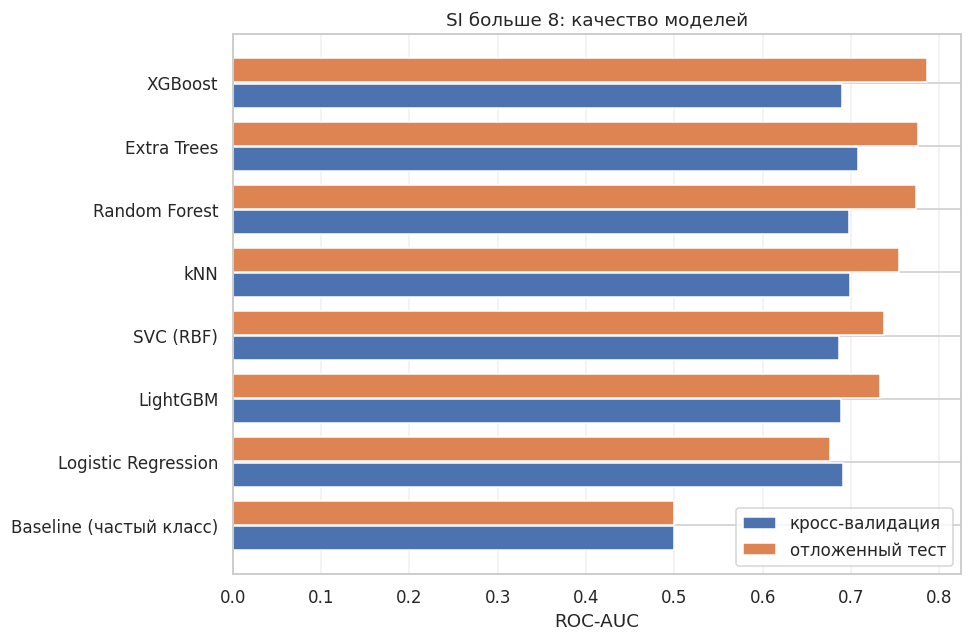

In [7]:
mdl.plot_cv_vs_test(
    cv_table, test_table, "CV roc_auc", "ROC-AUC",
    "SI больше 8: качество моделей",
    save_path=FIG_DIR / "si8_clf_models_comparison.png",
)

## 5. ROC и PR-кривые

Лучшая модель на тесте: XGBoost


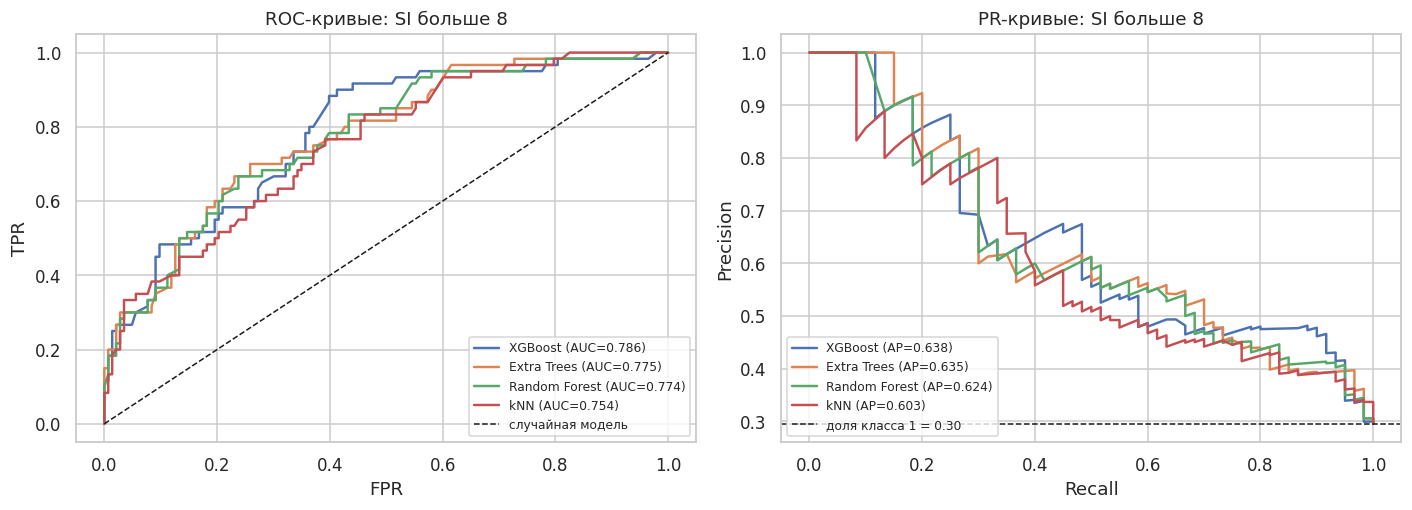

In [8]:
best_name = test_table.iloc[0]["модель"]
best_model = fitted[best_name]
print(f"Лучшая модель на тесте: {best_name}")

top_names = [n for n in test_table["модель"].head(4)]
curves = {n: fitted[n].predict_proba(X_test)[:, 1] for n in top_names}
mdl.plot_classification_diagnostics(
    y_test.to_numpy(), curves, "SI больше 8",
    save_path=FIG_DIR / "si8_clf_roc_pr.png",
)

## 6. Матрица ошибок и выбор порога

Оптимальный по F1 порог (подобран на train): 0.34


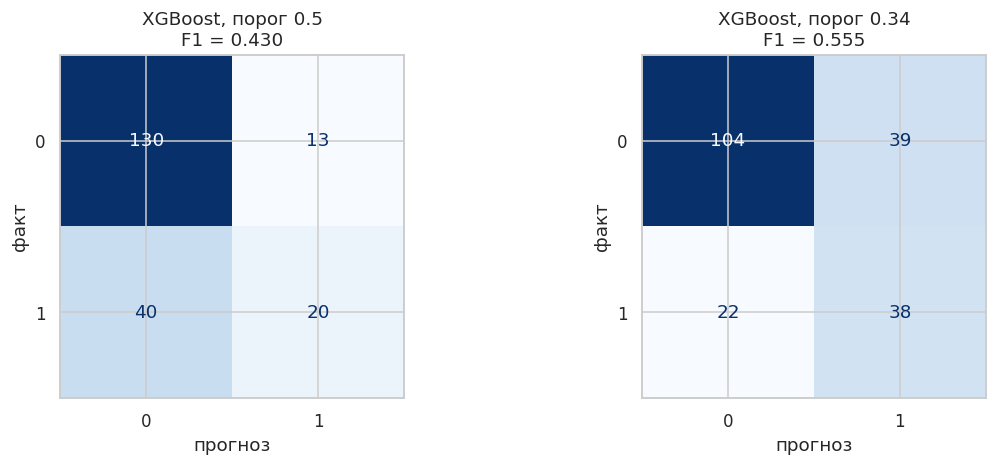

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

proba_train = best_model.predict_proba(X_train)[:, 1]
grid = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(y_train, (proba_train >= t).astype(int)) for t in grid]
best_threshold = float(grid[int(np.argmax(f1_scores))])
print(f"Оптимальный по F1 порог (подобран на train): {best_threshold:.2f}")

proba_test = best_model.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, threshold, label in [
    (axes[0], 0.5, "порог 0.5"),
    (axes[1], best_threshold, f"порог {best_threshold:.2f}"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, (proba_test >= threshold).astype(int), ax=ax,
        colorbar=False, cmap="Blues",
    )
    ax.set_title(f"{best_name}, {label}\n"
                 f"F1 = {f1_score(y_test, (proba_test >= threshold).astype(int)):.3f}")
    ax.set_xlabel("прогноз")
    ax.set_ylabel("факт")
plt.tight_layout()
plt.savefig(FIG_DIR / "si8_clf_confusion.png", dpi=140, bbox_inches="tight")
plt.show()

## 7. Какие дескрипторы определяют прогноз

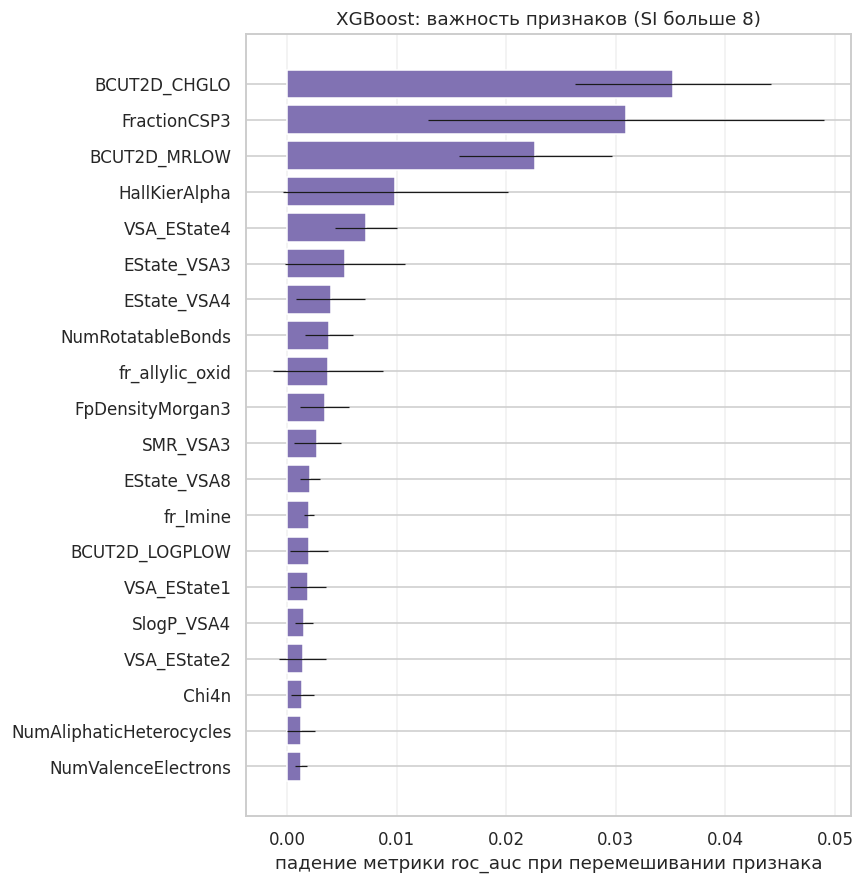

,признак,падение качества,std
0,BCUT2D_CHGLO,0.0352,0.0089
1,FractionCSP3,0.0309,0.0180
2,BCUT2D_MRLOW,0.0227,0.0070
3,HallKierAlpha,0.0099,0.0103
4,VSA_EState4,0.0072,0.0028
5,EState_VSA3,0.0053,0.0055
6,EState_VSA4,0.0040,0.0032
7,NumRotatableBonds,0.0038,0.0022
8,fr_allylic_oxid,0.0037,0.0050
9,FpDensityMorgan3,0.0034,0.0022


In [10]:
importance = mdl.plot_permutation_importance(
    best_model, X_test, y_test, scoring="roc_auc",
    title=f"{best_name}: важность признаков (SI больше 8)",
    save_path=FIG_DIR / "si8_clf_importance.png",
)
display(importance.head(15).round(4))
importance.to_csv(RES_DIR / "si8_clf_importance.csv", index=False)

## 8. Устойчивость результата

In [11]:
from sklearn.metrics import roc_auc_score

stability = mdl.stability_check(
    best_model, features, target, groups,
    scoring=lambda y_true, model, X: roc_auc_score(
        y_true, model.predict_proba(X)[:, 1]),
)
display(stability.round(4))

Среднее = 0.7078, std = 0.0520, размах = 0.1429


,seed,метрика
0,0,0.6241
1,1,0.7670
2,2,0.7194
3,3,0.7087
4,4,0.7201


## 9. Выводы по задаче «SI > 8»

### Что показали модели
(красивую табилцу попросил у дипсика сделать , каюсь, зато приятнее для понимания) - как и во всех остальных ноутбуках 

| Наблюдение | Интерпретация |
|---|---|
| CV ROC-AUC ≈ 0.71, на тесте до 0.79 | Сопоставимо с задачей «SI > медианы»; предметный порог не оказался труднее статистического |
| PR-AUC лучшей модели ≈ 0.64 при базовом уровне 0.30 | Более чем двукратное превышение случайного уровня — ключевая цифра для этой задачи |
| Baseline даёт accuracy 0.70, а лучшая модель — 0.74 | Наглядная иллюстрация непригодности accuracy при дисбалансе: прирост в 4 п.п. выглядит скромно, тогда как ROC-AUC вырос с 0.50 до 0.79 |
| Порог 0.5 даёт низкий F1; оптимизация порога по F1 на обучающей выборке заметно улучшает баланс полноты и точности | При дисбалансе порог обязательно нужно настраивать под задачу, а не брать по умолчанию |
| Результаты близки к задаче «SI > медианы» | Ожидаемо: порог 8 лежит примерно на 64-м перцентиле SI, разметки двух задач совпадают у большинства объектов |

### Порог

На раннем этапе скрининга  порог стоит смещать в сторону полноты, пропустить перспективную молекулу дороже, чем потратиться на лишний тест. Модель выдаёт калиброванную вероятность, так что порог можно менять без переобучения

### Рекомендация

По кросс-валидации лучший результат у Extra Trees. XGBoost чуть лучше выступил на конкретном тестовом разбиении, но их метрики близки. Думаю имеет смысл усреднять вероятности двух моделей такой союз даст небольшой прирост
